# Git Explainer Eval Workbench

This notebook gives you an interactive place to:

- run the agent on a single query against the local project
- run an offline-friendly smoke version of the benchmark or the full suite
- save notebook results to `eval/results.notebook.json`
- plot pass/fail counts, retrieval accuracy, citation metrics, faithfulness proxy, and latency
- separate **functional**, **external-repo**, and **adversarial** cases so aggregates are not misleading


In [18]:
from __future__ import annotations

import sys
import time
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import JSON, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "git_explainer").exists() and (candidate / "eval").exists():
            return candidate
    raise RuntimeError("Could not find the project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EVAL_DIR = PROJECT_ROOT / "eval"
RESULTS_PATH = EVAL_DIR / "results.notebook.json"

from eval.evaluate import load_benchmark, run_case, save_results, setup_repos, summarize_scores
from git_explainer.orchestrator import explain_code_history

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

print(f"Project root: {PROJECT_ROOT}")
print(f"Eval directory: {EVAL_DIR}")
print(f"Notebook results path: {RESULTS_PATH}")


Project root: /Users/alistairking/Projects/upenn-courses/cis-1990/CIS_1990_Final_Project
Eval directory: /Users/alistairking/Projects/upenn-courses/cis-1990/CIS_1990_Final_Project/eval
Notebook results path: /Users/alistairking/Projects/upenn-courses/cis-1990/CIS_1990_Final_Project/eval/results.notebook.json


## Notebook Configuration

The defaults below are chosen so the notebook can exercise the local repo without requiring LLM or GitHub access. Flip `RUN_FULL_BENCHMARK` and `OFFLINE_MODE` when you want the complete PRD-style run.


In [19]:
USE_LLM = False

AGENT_QUERY = {
    "file_path": "git_explainer/orchestrator.py",
    "question": "Why does the agent fall back to a deterministic summary?",
    "owner": None,
    "repo_name": None,
}

RUN_FULL_BENCHMARK = False
OFFLINE_MODE = True

SELECTED_IDS = [
    "file-reader-revision-fix",
    "line-range-slice-fix",
    "question-issue-lookup-library",
    "adversarial-end-before-start",
]
SELECTED_TAGS = None

# For the full benchmark, switch to:
# RUN_FULL_BENCHMARK = True
# OFFLINE_MODE = False
# SELECTED_IDS = None


In [20]:
def selected_cases(all_cases):
    cases = list(all_cases)
    if RUN_FULL_BENCHMARK:
        return cases
    if SELECTED_IDS:
        selected = set(SELECTED_IDS)
        return [case for case in cases if case.id in selected]
    if SELECTED_TAGS:
        selected_tags = set(SELECTED_TAGS)
        return [case for case in cases if selected_tags.intersection(case.tags)]
    return cases


def prepare_cases_for_notebook(all_cases):
    prepared = []
    skipped = []
    for case in selected_cases(all_cases):
        candidate = deepcopy(case)
        if OFFLINE_MODE and (candidate.expected.get("pr_numbers") or candidate.expected.get("issue_numbers")):
            skipped.append((candidate.id, "requires GitHub metadata for its checks"))
            continue
        if OFFLINE_MODE and candidate.repo_name == PROJECT_ROOT.name:
            candidate.repo_url = str(PROJECT_ROOT)
            candidate.owner = None
            candidate.repo_name = None
        prepared.append(candidate)
    return prepared, skipped


def categorize_case(case) -> str:
    tags = set(case.tags or [])
    if "adversarial" in tags:
        return "adversarial"
    if "external-repo" in tags:
        return "external"
    return "functional"


def case_id_to_category(cases) -> dict[str, str]:
    return {c.id: categorize_case(c) for c in cases}


def case_scores_frame(scores, cases):
    id_to_cat = case_id_to_category(cases)
    rows = []
    for score in scores:
        faithfulness = score.metrics.get("faithfulness_rubric", {})
        rows.append(
            {
                "case_id": score.case_id,
                "category": id_to_cat.get(score.case_id, "functional"),
                "status": "error" if score.error else ("passed" if score.passed else "failed"),
                "elapsed_seconds": score.elapsed_seconds,
                "retrieval_accuracy": score.metrics.get("retrieval_accuracy"),
                "citation_coverage": score.metrics.get("citation_coverage"),
                "citation_validity": score.metrics.get("citation_validity"),
                "faithfulness_overall": faithfulness.get("overall"),
                "checks": ", ".join(name for name, ok in score.checks.items() if not ok),
                "error": score.error,
            }
        )
    if not rows:
        return pd.DataFrame(
            columns=[
                "case_id",
                "category",
                "status",
                "elapsed_seconds",
                "retrieval_accuracy",
                "citation_coverage",
                "citation_validity",
                "faithfulness_overall",
                "checks",
                "error",
            ]
        )
    frame = pd.DataFrame(rows)
    return frame.sort_values(["status", "case_id"]).reset_index(drop=True)


def _score_by_case_id(scores):
    return {s.case_id: s for s in scores}


def category_breakdown_df(cases, scores) -> pd.DataFrame:
    by_id = _score_by_case_id(scores)
    rows: list[dict[str, object]] = []
    for category in ("functional", "external", "adversarial"):
        cids = [c.id for c in cases if categorize_case(c) == category]
        if not cids:
            continue
        passed = sum(1 for cid in cids if by_id[cid].passed and not by_id[cid].error)
        failed = sum(1 for cid in cids if not by_id[cid].passed and not by_id[cid].error)
        err = sum(1 for cid in cids if by_id[cid].error)
        row: dict[str, object] = {
            "category": category,
            "cases": len(cids),
            "passed": passed,
            "failed": failed,
            "errors": err,
        }
        if category == "adversarial":
            row["mean_retrieval_accuracy"] = None
            row["mean_citation_coverage"] = None
            row["mean_faithfulness"] = None
        else:
            retr: list[float] = []
            cov: list[float] = []
            ff: list[float] = []
            for cid in cids:
                s = by_id[cid]
                m = s.metrics
                r = m.get("retrieval_accuracy")
                if r is not None:
                    retr.append(float(r))
                c = m.get("citation_coverage")
                if c is not None:
                    cov.append(float(c))
                f = m.get("faithfulness_rubric", {}).get("overall")
                if f is not None:
                    ff.append(float(f))
            row["mean_retrieval_accuracy"] = round(sum(retr) / len(retr), 3) if retr else None
            row["mean_citation_coverage"] = round(sum(cov) / len(cov), 3) if cov else None
            row["mean_faithfulness"] = round(sum(ff) / len(ff), 3) if ff else None
        rows.append(row)
    return pd.DataFrame(rows)


def _ratio_as_pct(value: object, decimals: int = 1) -> str:
    if value is None:
        return "n/a"
    try:
        return f"{float(value) * 100:.{decimals}f}%"
    except (TypeError, ValueError):
        return "n/a"


def summary_display_df(summary: dict, cases, scores) -> pd.DataFrame:
    rows: list[dict[str, str]] = [
        {"metric": "Pass rate (all cases)", "value": _ratio_as_pct(summary.get("pass_rate"))},
        {
            "metric": "Retrieval accuracy (aggregate)",
            "value": _ratio_as_pct(summary["retrieval"].get("accuracy")),
        },
        {
            "metric": "Citation coverage (aggregate)",
            "value": _ratio_as_pct(summary["citation"].get("coverage")),
        },
        {
            "metric": "Citation validity (aggregate)",
            "value": _ratio_as_pct(summary["citation"].get("validity")),
        },
    ]
    avg_ff = summary["faithfulness_rubric"].get("average")
    if avg_ff is not None:
        rows.append({"metric": "Faithfulness proxy (avg /5)", "value": f"{float(avg_ff):.2f} / 5.00"})
    else:
        rows.append({"metric": "Faithfulness proxy (avg /5)", "value": "n/a"})
    rows.append(
        {"metric": "Avg latency", "value": f"{(summary['latency'].get('average_seconds') or 0):.3f} s"}
    )
    rows.append({"metric": "P95 latency", "value": f"{(summary['latency'].get('p95_seconds') or 0):.3f} s"})
    by_id = _score_by_case_id(scores)
    for category, label in (
        ("functional", "Pass rate (functional only)"),
        ("external", "Pass rate (external only)"),
        ("adversarial", "Pass rate (adversarial only)"),
    ):
        cids = [c.id for c in cases if categorize_case(c) == category]
        if not cids:
            rows.append({"metric": label, "value": "n/a (no cases)"})
            continue
        p = sum(1 for cid in cids if by_id[cid].passed and not by_id[cid].error)
        rows.append({"metric": label, "value": f"{p}/{len(cids)} passed ({100 * p / len(cids):.1f}%)"})
    return pd.DataFrame(rows)


def format_case_df_for_display(case_df: pd.DataFrame) -> pd.DataFrame:
    df = case_df.copy()
    metric_cols = [
        "retrieval_accuracy",
        "citation_coverage",
        "citation_validity",
        "faithfulness_overall",
    ]

    def fmt_num(value: object) -> str:
        if value is None or (isinstance(value, float) and pd.isna(value)):
            return "n/a"
        if isinstance(value, (int, float)):
            return f"{float(value):.3f}"
        return str(value)

    for column in metric_cols:
        if column in df.columns:
            df[column] = df[column].apply(fmt_num)
    if "error" in df.columns:
        err_series = df["error"]
        has_any = err_series.notna() & err_series.astype(str).str.strip().ne("") & err_series.astype(str).ne("None")
        if not has_any.any():
            df = df.drop(columns=["error"])
    return df


def style_case_table(df: pd.DataFrame):
    def status_css(val: object) -> str:
        if val == "passed":
            return "font-weight: 600; color: #2b8a3e"
        if val == "failed":
            return "font-weight: 600; color: #c92a2a"
        if val == "error":
            return "font-weight: 600; color: #e67700"
        return ""

    return df.style.map(status_css, subset=["status"])


## Single Agent Query

This is a quick sanity-check cell for the agent itself before running the benchmark.


In [21]:
single_result = explain_code_history(
    repo_path=str(PROJECT_ROOT),
    file_path=AGENT_QUERY["file_path"],
    question=AGENT_QUERY["question"],
    owner=AGENT_QUERY["owner"],
    repo_name=AGENT_QUERY["repo_name"],
    use_llm=USE_LLM,
)

# display(JSON(single_result, expanded=False))


## Benchmark Run

The default configuration uses a smoke subset that stays local and deterministic. When you are ready for the full suite, turn off offline mode and flip `RUN_FULL_BENCHMARK` in the config cell.


In [22]:
benchmark_cases = load_benchmark(EVAL_DIR / "benchmark.json")
cases_to_run, skipped_cases = prepare_cases_for_notebook(benchmark_cases)

print(f"Loaded {len(benchmark_cases)} benchmark cases.")
if skipped_cases:
    print("Skipped in this notebook configuration:")
    for case_id, reason in skipped_cases:
        print(f"- {case_id}: {reason}")

if not cases_to_run:
    raise RuntimeError("No benchmark cases remain after applying the notebook filters.")

repo_map = setup_repos(cases_to_run)
scores = []
benchmark_start = time.monotonic()

for index, case in enumerate(cases_to_run, start=1):
    print(f"[{index}/{len(cases_to_run)}] Running {case.id}...")
    scores.append(run_case(case, repo_map.get(case.repo_url, ""), no_llm=not USE_LLM))

benchmark_elapsed = time.monotonic() - benchmark_start
summary = summarize_scores(cases_to_run, scores, benchmark_elapsed)
save_results(scores, summary, RESULTS_PATH)

print(f"Saved notebook results to {RESULTS_PATH}")
display(JSON(summary, expanded=True))


Loaded 20 benchmark cases.
[1/4] Running file-reader-revision-fix...
[2/4] Running line-range-slice-fix...
[3/4] Running question-issue-lookup-library...
[4/4] Running adversarial-end-before-start...
Saved notebook results to /Users/alistairking/Projects/upenn-courses/cis-1990/CIS_1990_Final_Project/eval/results.notebook.json


<IPython.core.display.JSON object>

In [23]:
from IPython.display import Markdown, display

summary_df = summary_display_df(summary, cases_to_run, scores)
display(summary_df)
display(
    Markdown(
        "**Disclaimer:** *Faithfulness* scores are a **proxy** in this harness: they reward "
        "non-empty sections and well-formed citations grounded in retrieved commits/PRs/issues, "
        "not independent verification of factual correctness. Citation coverage is also close to a "
        "format-compliance metric because both the prompt and fallback summary require citations in "
        "every sentence."
    )
)

case_df = case_scores_frame(scores, cases_to_run)
display(style_case_table(format_case_df_for_display(case_df)))


,metric,value
0,Pass rate (all cases),100.0%
1,Retrieval accuracy (aggregate),100.0%
2,Citation coverage (aggregate),100.0%
3,Citation validity (aggregate),100.0%
4,Faithfulness proxy (avg /5),5.00 / 5.00
5,Avg latency,0.125 s
6,P95 latency,0.192 s
7,Pass rate (functional only),3/3 passed (100.0%)
8,Pass rate (external only),n/a (no cases)
9,Pass rate (adversarial only),1/1 passed (100.0%)


**Disclaimer:** *Faithfulness* scores are a **proxy** in this harness: they reward non-empty sections and well-formed citations grounded in retrieved commits/PRs/issues, not independent verification of factual correctness. Citation coverage is also close to a format-compliance metric because both the prompt and fallback summary require citations in every sentence.

,case_id,category,status,elapsed_seconds,retrieval_accuracy,citation_coverage,citation_validity,faithfulness_overall,checks
0,adversarial-end-before-start,adversarial,passed,0.000000,n/a,n/a,n/a,n/a,
1,file-reader-revision-fix,functional,passed,0.198000,1.000,1.000,1.000,5.000,
2,line-range-slice-fix,functional,passed,0.159000,1.000,1.000,1.000,5.000,
3,question-issue-lookup-library,functional,passed,0.142000,1.000,1.000,1.000,5.000,


In [24]:
from IPython.display import Markdown, display

display(Markdown("#### Per-category breakdown"))
breakdown_df = category_breakdown_df(cases_to_run, scores)
display(breakdown_df)

#### Per-category breakdown

,category,cases,passed,failed,errors,mean_retrieval_accuracy,mean_citation_coverage,mean_faithfulness
0,functional,3,3,0,0,1.0,1.0,5.0
1,adversarial,1,1,0,0,NaN,NaN,NaN


## Plots

These six panels summarize outcomes by case category, aggregate quality metrics on **non-adversarial** cases only (so missing metrics are not misread as zeros), per-case evidence where applicable, faithfulness sub-scores, and latency.


/var/folders/y6/_j7ssqmx6rj_4yw4wmyjxjz80000gn/T/ipykernel_63806/354307968.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


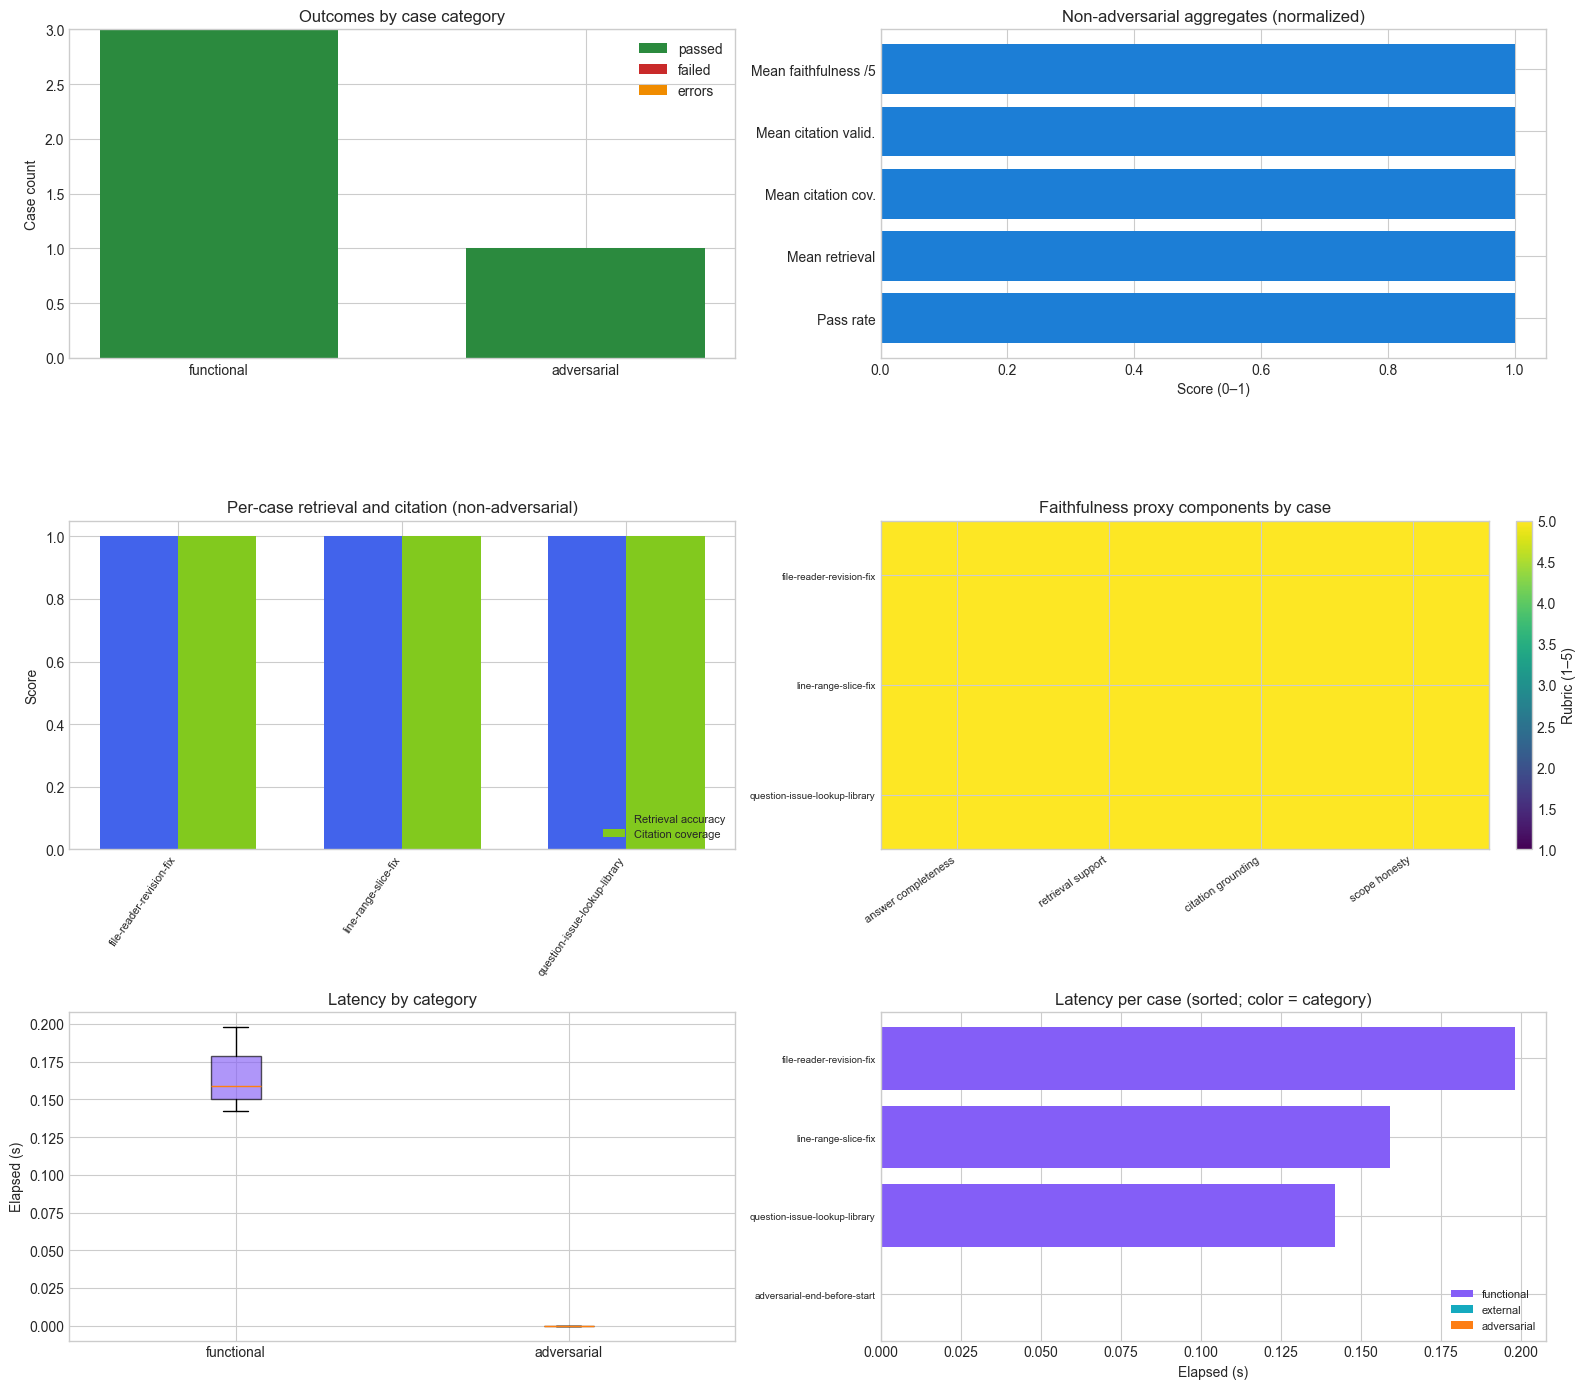

In [25]:
import numpy as np
from matplotlib.patches import Patch

if case_df.empty:
    raise RuntimeError("Run the benchmark tables cell before plotting results.")

status_colors = {"passed": "#2b8a3e", "failed": "#c92a2a", "error": "#f08c00"}
category_palette = {"functional": "#845ef7", "external": "#15aabf", "adversarial": "#fd7e14"}
category_axis_order = ["functional", "external", "adversarial"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# --- Panel 1: stacked outcomes by category ---
ax = axes[0, 0]
cats = [c for c in category_axis_order if (case_df["category"] == c).any()]
x = np.arange(len(cats))
bottom = np.zeros(len(cats))
for label, status_key, color in (
    ("passed", "passed", status_colors["passed"]),
    ("failed", "failed", status_colors["failed"]),
    ("errors", "error", status_colors["error"]),
):
    heights = np.array(
        [((case_df["category"] == c) & (case_df["status"] == status_key)).sum() for c in cats],
        dtype=float,
    )
    ax.bar(x, heights, bottom=bottom, label=label, color=color, width=0.65)
    bottom += heights
ax.set_xticks(x, cats)
ax.set_title("Outcomes by case category")
ax.set_ylabel("Case count")
ax.legend(loc="upper right")

# --- Panel 2: aggregate metrics (functional + external only), normalized to 0–1 ---
ax = axes[0, 1]
non_adv = case_df[case_df["category"].isin(["functional", "external"])]
if len(non_adv) == 0:
    ax.text(0.5, 0.5, "No non-adversarial cases", ha="center", va="center", transform=ax.transAxes)
else:
    pass_rate = float((non_adv["status"] == "passed").mean())
    mean_ret = non_adv["retrieval_accuracy"].mean()
    mean_cov = non_adv["citation_coverage"].mean()
    mean_val = non_adv["citation_validity"].mean()
    mean_ff = non_adv["faithfulness_overall"].mean()
    series = {
        "Pass rate": pass_rate,
        "Mean retrieval": 0.0 if pd.isna(mean_ret) else float(mean_ret),
        "Mean citation cov.": 0.0 if pd.isna(mean_cov) else float(mean_cov),
        "Mean citation valid.": 0.0 if pd.isna(mean_val) else float(mean_val),
        "Mean faithfulness /5": (0.0 if pd.isna(mean_ff) else float(mean_ff)) / 5.0,
    }
    names = list(series.keys())
    vals = list(series.values())
    ax.barh(names, vals, color="#1c7ed6")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Score (0–1)")
ax.set_title("Non-adversarial aggregates (normalized)")

# --- Panel 3: per-case retrieval + citation (non-adversarial only) ---
ax = axes[1, 0]
plot_cases = case_df[case_df["category"].isin(["functional", "external"])].sort_values("case_id")
if plot_cases.empty:
    ax.text(0.5, 0.5, "No cases to plot", ha="center", va="center", transform=ax.transAxes)
else:
    idx = np.arange(len(plot_cases))
    width = 0.35
    ax.bar(
        idx - width / 2,
        plot_cases["retrieval_accuracy"],
        width,
        label="Retrieval accuracy",
        color="#4263eb",
    )
    ax.bar(
        idx + width / 2,
        plot_cases["citation_coverage"],
        width,
        label="Citation coverage",
        color="#82c91e",
    )
    ax.set_xticks(idx, plot_cases["case_id"], rotation=55, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right", fontsize=8)
ax.set_ylabel("Score")
ax.set_title("Per-case retrieval and citation (non-adversarial)")

# --- Panel 4: faithfulness component heatmap (non-adversarial) ---
ax = axes[1, 1]
comp_order = ["answer_completeness", "retrieval_support", "citation_grounding", "scope_honesty"]
id_to_cat = case_id_to_category(cases_to_run)
matrix_rows: list[list[float]] = []
labels_y: list[str] = []
for score in scores:
    if id_to_cat.get(score.case_id) == "adversarial":
        continue
    comps = (score.metrics.get("faithfulness_rubric") or {}).get("components") or {}
    row = [float(comps.get(k, float("nan"))) for k in comp_order]
    if all(np.isnan(row)):
        continue
    matrix_rows.append(row)
    cid = score.case_id
    labels_y.append(cid if len(cid) <= 32 else cid[:29] + "...")
if matrix_rows:
    mat = np.array(matrix_rows)
    im = ax.imshow(mat, aspect="auto", vmin=1.0, vmax=5.0, cmap="viridis")
    ax.set_xticks(
        range(len(comp_order)),
        [c.replace("_", " ") for c in comp_order],
        rotation=35,
        ha="right",
        fontsize=8,
    )
    ax.set_yticks(range(len(labels_y)), labels_y, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Rubric (1–5)")
else:
    ax.text(0.5, 0.5, "No component data", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Faithfulness proxy components by case")

# --- Panel 5: latency distribution by category ---
ax = axes[2, 0]
groups = [
    case_df.loc[case_df["category"] == c, "elapsed_seconds"].values
    for c in category_axis_order
    if (case_df["category"] == c).any()
]
labels = [c for c in category_axis_order if (case_df["category"] == c).any()]
if groups:
    bp = ax.boxplot(groups, labels=labels, patch_artist=True)
    for patch, lab in zip(bp["boxes"], labels):
        patch.set_facecolor(category_palette.get(lab, "#adb5bd"))
        patch.set_alpha(0.65)
ax.set_ylabel("Elapsed (s)")
ax.set_title("Latency by category")

# --- Panel 6: latency per case (sorted), color by category ---
ax = axes[2, 1]
lat_sorted = case_df.sort_values("elapsed_seconds", ascending=True)
bar_colors = [category_palette.get(c, "#868e96") for c in lat_sorted["category"]]
ax.barh(lat_sorted["case_id"], lat_sorted["elapsed_seconds"], color=bar_colors)
ax.set_xlabel("Elapsed (s)")
ax.set_title("Latency per case (sorted; color = category)")
ax.tick_params(axis="y", labelsize=7)

legend_handles = [
    Patch(facecolor=category_palette[k], edgecolor="none", label=k)
    for k in ("functional", "external", "adversarial")
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


### Caveats (how to read these numbers)

- **Faithfulness** is a *proxy* rubric derived from this repo’s harness: it rewards completeness, retrieval overlap with gold checks, and citation formatting/validity—not human-judged factual correctness.
- **Retrieval accuracy** is **recall** against hand-picked targets in `benchmark.json` (commit phrases, PR/issue numbers, resolved paths). It is **not** precision against the full GitHub graph.
- **Citation coverage** is near-ceiling by construction: the synthesis prompt and deterministic fallback both require bracketed citations in every sentence, so this metric mostly measures formatting compliance rather than evidentiary strength.
- **Faithfulness** becomes especially optimistic on cases without gold retrieval targets: when the harness has no retrieval denominator, the rubric can still award strong retrieval support if the agent returns any commits or a resolved target.
- **External-repo** cases currently have little or no retrieval ground truth, so they can pass without demonstrating precise commit/PR/issue retrieval.
- **Some checks are structurally weak**: entries like `pr_numbers: []` or `issue_numbers: []` always pass under the current scorer, and many `explanation_contains` checks only require a filename or citation token.
- **Adversarial** cases test **guardrails** (expected errors, injection resilience). They are reported separately from functional and external-repo cases; do not interpret missing retrieval/citation metrics on those rows as “bad scores.”